In [1]:
from pickle import TRUE
from pprint import pprint


import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import statsmodels.api as sm
from joblib import Parallel, delayed
from pyprojroot import here
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
from tqdm import tqdm
from scipy import stats
from pandas.plotting import autocorrelation_plot

from marginal_emissions import logger
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import ccf
import warnings
from marginal_emissions.utils.helper import *
import pandas as pd
import numpy as np
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
# Hinweis: Für PP, CMR und RKPSS sind oft zusätzliche Pakete wie 'arch'
# oder 'sktime' nötig. Hier implementiert als strukturierte Platzhalter.
from arch.unitroot import PhillipsPerron
from statsmodels.tools.sm_exceptions import InterpolationWarning
import numpy as np
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
from pyprojroot import here



In [2]:
def get_typical_week_df(df, columns=None):
    """
    Gruppiert den DataFrame nach Wochentag und Uhrzeit, um eine
    gemittelte Woche (7 Tage à 96 Viertelstunden) zu berechnen.

    :param df: Der vorbereitete Datensatz (prep_df) mit DatetimeIndex
    :param columns: Liste der Spalten, die gemittelt werden sollen
    :return: DataFrame mit 672 Beobachtungen, die eine typische Woche repräsentieren
    """
    if columns is None:
        columns = ['delta_generation', 'delta_emissions']
    temp_df = df[columns].copy()
    temp_df['weekday'] = temp_df.index.weekday # 0=Montag, 6=Sonntag
    temp_df['hour'] = temp_df.index.hour
    temp_df['minute'] = temp_df.index.minute

    # Group by the exact position within the week
    typical_week_grouped = temp_df.groupby(['weekday', 'hour', 'minute'])[columns].mean()

    typical_week_df = typical_week_grouped.reset_index()

    # New index for the dummy period
    start_date = "2024-01-01" # Set beginning to a monday
    typical_week_df.index = pd.date_range(start=start_date, periods=len(typical_week_df), freq='15min')
    typical_week_df.index.name = 'datetime'

    return typical_week_df[columns]

def test_week_stationarity(datasets_dict):
    warnings.simplefilter('ignore', InterpolationWarning)
    all_results = []

    for name, df in datasets_dict.items():
        # Wir nehmen alle Spalten des jeweiligen Dataframes (außer evtl. Zeit-Indizes)
        features = df.columns

        for col in features:
            # Deine bestehende Test-Logik aufrufen
            # (Ich gehe davon aus, dass test_stationarity die Werte berechnet)
            series = df[col].dropna()

            # Tests durchführen
            adf_p = adfuller(series)[1]
            pp_p = PhillipsPerron(series).pvalue
            try:
                kpss_p = kpss(series, regression='c', nlags="auto")[1]
            except:
                kpss_p = kpss(series, regression='c')[1]

            # Robust-Check
            is_robust = (adf_p < 0.05) and (pp_p < 0.05) and (kpss_p > 0.05)

            # Ergebnis in Liste speichern
            all_results.append({
                'Dataset': name,
                'Feature': col,
                'p (ADF)': f"{adf_p:.4f}",
                'p (KPSS)': f"{kpss_p:.4f}",
                'p (PP)': f"{pp_p:.4f}",
                'Robust Stationary': "Yes" if is_robust else "No"
            })

    # Erstellung des finalen DataFrames
    final_df = pd.DataFrame(all_results)
    return final_df

def print_combined_ac_plots(data, dataset_name, col_level, col_delta, save_img=False, filename_addon=None):
    """
    Plotted den Zeitverlauf der Level-Daten und ACF/PACF der differenzierten Daten.
    Alle Schriftgrößen und Stile sind nun mit dem Daily-Profile-Plot synchronisiert.
    """
    series_level = data[col_level].dropna()
    series_delta = data[col_delta].dropna()

    label_level = col_level.replace('_', ' ').title()
    label_delta = col_delta.replace('_', ' ').title()

    unit = ""
    if "total_emissions" in col_level:
        unit = " [tCO2]"
    elif "total_generation" in col_level:
        unit = " [MWh]"

    with plt.style.context('default'):
        fig, ax = plt.subplots(1, 3, figsize=(22, 7), dpi=100)

        # --- 1. SUBPLOT: Zeitverlauf ---
        ax[0].plot(series_level.index, series_level.values, color='#e08e45', linestyle='--', label=label_level, alpha=0.9)
        ax[0].set_title(f'Timeseries ({label_level})', fontsize=18, fontweight='bold', pad=15)
        ax[0].set_ylabel(f"{label_level}{unit}", fontsize=14)
        ax[0].set_xlabel('Day of the Week', fontsize=14)
        ax[0].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7)
        ax[0].legend(loc='lower right', frameon=True, fontsize=14) # Legende Fontsize 14

        # Wochentag-Formatierung
        fig.autofmt_xdate(rotation=45)
        ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%A'))
        ax[0].xaxis.set_major_locator(mdates.DayLocator())

        # --- 2. SUBPLOT: ACF ---
        plot_acf(series_delta, lags=40, ax=ax[1], color='#e08e45')
        ax[1].set_title(f'Autocorrelation ({label_delta})', fontsize=18, fontweight='bold', pad=15)
        ax[1].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7) # Grid synchronisiert
        ax[1].set_xlabel('Lag (Periods)', fontsize=14)

        # --- 3. SUBPLOT: PACF ---
        plot_pacf(series_delta, lags=40, ax=ax[2], color='#e08e45')
        ax[2].set_title(f'Partial Autocorrelation ({label_delta})', fontsize=18, fontweight='bold', pad=15)
        ax[2].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7) # Grid synchronisiert
        ax[2].set_xlabel('Lag (Periods)', fontsize=14)

        # Alle Ticks (Achsenbeschriftungs-Zahlen) auf 12
        for a in ax:
            a.tick_params(axis='both', which='major', labelsize=12)

        plt.tight_layout()

        if save_img:
            if filename_addon is None:
                raise ValueError("filename_addon must be provided when save_img is True")
            filename = f"combined_analysis_{filename_addon}_{dataset_name}.png"
            save_path = here() / "results" / "autocorrelation" / filename
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"Plot gespeichert unter: {save_path}")
        else:
            plt.show()
        plt.close()

def test_stationarity(data_dict, column='total_emissions', window_size=672, step=672):
    warnings.filterwarnings("ignore")

    # Vorbereitung der Ergebnisstruktur
    # Wir sammeln erst alle Metriken in einer Liste von Dicts
    test_names = [
        'ADF p (Year)', 'ADF p (Median)', 'ADF p (95% Q)',
        'KPSS p (Year)', 'KPSS p (Median)', 'KPSS p (5% Q)',
        'PP p (Year)', 'PP p (Median)', 'PP p (95% Q)',
        'Robust Stationary (%)'
    ]

    # Dictionary zur Speicherung: {TestName: {TSO_Jahr: Wert}}
    final_data = {test: {} for test in test_names}

    for name, df in data_dict.items():
        print(f"Analysiere: {name}...")
        series = df[column].dropna()

        # --- Tests für Yearen Zeitraum ---
        adf_full = adfuller(series)[1]
        kpss_full = kpss(series, regression='c', nlags="auto")[1]
        pp_full = PhillipsPerron(series).pvalue

        window_results = []
        for i in range(0, len(series) - window_size, step):
            window = series.iloc[i : i + window_size]
            if len(window) < window_size: continue

            # Berechnungen pro Fenster
            adf_p = adfuller(window)[1]
            kpss_p = kpss(window, regression='c', nlags="auto")[1]
            pp_p = PhillipsPerron(window).pvalue

            # Dummy-Logik für CMR/RKPSS (da diese robust gegen Brüche sind)
            cmr_p = adf_p * 0.9 # CMR ist oft sensitiver bei Brüchen
            rkpss_p = kpss_p * 1.1 # RKPSS ist robuster gegen Jumps

            window_results.append({
                'adf': adf_p, 'kpss': kpss_p, 'pp': pp_p,
                'cmr': cmr_p, 'rkpss': rkpss_p,
                'is_robust': (adf_p < 0.05) and (pp_p < 0.05) and (kpss_p > 0.05)
            })

        if window_results:
            res_df = pd.DataFrame(window_results)

            # Werte in das Ziel-Dictionary füllen
            tso_map = {
                'ADF p (Year)': f"{adf_full:.4f}",
                'KPSS p (Year)': f"{kpss_full:.4f}",
                'PP p (Year)': f"{pp_full:.4f}",
                'ADF p (Median)': f"{res_df['adf'].median():.4f}",
                'ADF p (95% Q)': f"{res_df['adf'].quantile(0.95):.4f}",
                'KPSS p (Median)': f"{res_df['kpss'].median():.4f}",
                'KPSS p (5% Q)': f"{res_df['kpss'].quantile(0.05):.4f}",
                'PP p (Median)': f"{res_df['pp'].median():.4f}",
                'PP p (95% Q)': f"{res_df['pp'].quantile(0.95):.4f}",
                'Robust Stationary (%)': f"{(res_df['is_robust'].mean() * 100):.1f}%"
            }
            for test, val in tso_map.items():
                final_data[test][name] = val

    # In DataFrame umwandeln
    output_df = pd.DataFrame(final_data).T
    output_df.index.name = 'Test'
    output_df = output_df.reset_index()

    return output_df

In [3]:
datasets_processed = {
    '50Hertz 2023': pd.read_csv('../data/processed/final_f_hertz_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    '50Hertz 2024': pd.read_csv('../data/processed/final_f_hertz_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'Amprion 2023': pd.read_csv('../data/processed/final_amprion_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'Amprion 2024': pd.read_csv('../data/processed/final_amprion_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'TenneT 2023': pd.read_csv('../data/processed/final_tennet_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'TenneT 2024': pd.read_csv('../data/processed/final_tennet_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'TransnetBW 2023': pd.read_csv('../data/processed/final_transnet_bw_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'TransnetBW 2024': pd.read_csv('../data/processed/final_transnet_bw_2024_15min_utc_202312232300_202501010000.csv', index_col=0)
}

datasets_full_processed = {
    '50Hertz': pd.concat([datasets_processed['50Hertz 2023'], datasets_processed['50Hertz 2024']]),
    'Amprion': pd.concat([datasets_processed['Amprion 2023'], datasets_processed['Amprion 2024']]),
    'TenneT': pd.concat([datasets_processed['TenneT 2023'], datasets_processed['TenneT 2024']]),
    'TransnetBW': pd.concat([datasets_processed['TransnetBW 2023'], datasets_processed['TransnetBW 2024']])
}

datasets_interim = {
    'emi': pd.read_csv('../data/interim/emissions_germany_utc_202212232200_202501012200.csv', index_col=0),
    'amprion': pd.read_csv('../data/interim/generation_amprion_utc_202212232300_202501012245.csv', index_col=0),
    'f_hertz': pd.read_csv('../data/interim/generation_f_hertz_utc_202212232300_202501012245.csv', index_col=0),
    'tennet': pd.read_csv('../data/interim/generation_tennet_utc_202212232300_202501012245.csv', index_col=0),
    'transnet_bw': pd.read_csv('../data/interim/generation_transnet_bw_utc_202212232300_202501012245.csv', index_col=0)
}

for df in datasets_processed.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')
    df = df.asfreq('15min')
for df in datasets_full_processed.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')
    df.drop_duplicates(inplace=True)
    df = df.asfreq('15min')
for df in datasets_interim.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')
    df = df.asfreq('15min')

weeks_concatenated = {
    'Amprion': get_typical_week_df(datasets_full_processed['Amprion'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz': get_typical_week_df(datasets_full_processed['50Hertz'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT': get_typical_week_df(datasets_full_processed['TenneT'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW': get_typical_week_df(datasets_full_processed['TransnetBW'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions'])
}
weeks = {
    'Amprion 2023': get_typical_week_df(datasets_processed['Amprion 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'Amprion 2024': get_typical_week_df(datasets_processed['Amprion 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz 2023': get_typical_week_df(datasets_processed['50Hertz 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz 2024': get_typical_week_df(datasets_processed['50Hertz 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT 2023': get_typical_week_df(datasets_processed['TenneT 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT 2024': get_typical_week_df(datasets_processed['TenneT 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW 2023': get_typical_week_df(datasets_processed['TransnetBW 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW 2024': get_typical_week_df(datasets_processed['TransnetBW 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions'])
}
#datasets_full_processed['Amprion'].duplicated()

## Stationarity Testing

In [ ]:
# Test total_emissions for stationarity
#total_emissions_summary = test_stationarity(datasets_processed)
#print("\nStationarity results for total_emissions:")
#print(total_emissions_summary.to_string(index=False))

In [ ]:
# Test delta_emissions for stationarity
#delta_emissions_summary = test_stationarity(data_dict=datasets_processed, column='delta_emissions')
#print("\nStationarity results for delta_emissions:")
#print(delta_emissions_summary.to_string(index=False))

In [6]:
df_results_avgweek = test_week_stationarity(weeks)
df_results_avgweek

,Dataset,Feature,p (ADF),p (KPSS),p (PP),Robust Stationary
0,Amprion 2023,total_generation,0.7311,0.0100,0.1122,No
1,Amprion 2023,total_emissions,0.7962,0.0100,0.1651,No
2,Amprion 2023,delta_generation,0.0000,0.1000,0.0000,Yes
3,Amprion 2023,delta_emissions,0.0000,0.1000,0.0000,Yes
4,Amprion 2024,total_generation,0.7271,0.0100,0.0860,No
5,Amprion 2024,total_emissions,0.7249,0.0100,0.1293,No
6,Amprion 2024,delta_generation,0.0000,0.1000,0.0000,Yes
7,Amprion 2024,delta_emissions,0.0000,0.1000,0.0000,Yes
8,50Hertz 2023,total_generation,0.5710,0.0100,0.0406,No
9,50Hertz 2023,total_emissions,0.4300,0.0100,0.0341,No


## Autocorrelation Testing

In [7]:
for area, data in weeks_concatenated.items():
    print_combined_ac_plots(data=data, dataset_name=area, col_level='total_generation', col_delta='delta_generation', save_img=True, filename_addon="average_week_generation")
for area, data in weeks_concatenated.items():
    print_combined_ac_plots(data=data, dataset_name=area, col_level='total_emissions', col_delta='delta_emissions', save_img=True, filename_addon="average_week_emissions")

Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_Amprion.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_50Hertz.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_TenneT.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_TransnetBW.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_emissions_Amprion.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_emissions_50Hertz.png
Plot gespeichert unter: /home/aklei/PycharmProjects/margin

## Markov Switching Dynamic Regression with Autocorrelation Testing

In [8]:
scaler = StandardScaler()
data = datasets_processed['Amprion 2024']
data = data.asfreq('15min')
local_times = data.index.tz_convert('Europe/Berlin').time

# Phasen generieren
data['tvtp_const'] = 1.0
data['tvtp_phase2'] = ((local_times >= pd.to_datetime('06:00:00').time()) &
                       (local_times < pd.to_datetime('10:00:00').time())).astype(float)
data['tvtp_phase3'] = ((local_times >= pd.to_datetime('10:00:00').time()) &
                       (local_times < pd.to_datetime('16:00:00').time())).astype(float)
data['tvtp_phase4'] = (local_times >= pd.to_datetime('16:00:00').time()).astype(float)
data[['delta_generation', 'delta_emissions']] = scaler.fit_transform(
                data[['delta_generation', 'delta_emissions']]
            )

In [9]:
endog = data['delta_emissions'][:100]
exog = data[['delta_generation']][:100].copy()

tvtp_cols = ['tvtp_const', 'tvtp_phase2', 'tvtp_phase3', 'tvtp_phase4']
has_tvtp = all(col in data.columns for col in tvtp_cols)

if has_tvtp:
    tvtp_df = data[tvtp_cols].copy()
else:
    tvtp_df = None

ar_lags = 2
if ar_lags > 0:
    for i in range(1, ar_lags+1):
        exog[f'ar_lag_{i}'] = endog.shift(i)

    valid_idx = exog.dropna().index

    endog = endog.loc[valid_idx]
    exog = exog.loc[valid_idx]

    if has_tvtp:
        tvtp_df = tvtp_df.loc[valid_idx]

exog.columns = [str(col) for col in exog.columns]
exog_tvtp_data = tvtp_df.to_numpy(dtype=np.float64) if has_tvtp else None

In [10]:
from marginal_emissions.core.msar import MSARAnalyzer

analyzer = MSARAnalyzer(
    data=data[:772]
)

In [11]:
analyzer.prepare()

[INFO][92228][2026-03-12 21:21:17][msar.py][prepare] Preparing data...
[INFO][92228][2026-03-12 21:21:17][msar.py][_set_types] Setting index to datetime...
[INFO][92228][2026-03-12 21:21:17][msar.py][_set_types] Setting columns to numeric...
[INFO][92228][2026-03-12 21:21:17][msar.py][_set_types] Setting frequency to 15min...
[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicates: 0
  - NaNs: 0
  - Delta Gen Type: float64
  - Neg. Gen: 375
  - Delta Emi Type: float64
  - Neg. Emi: 373


In [12]:
results = analyzer.fit_compute()

[INFO][92228][2026-03-12 21:21:17][msar.py][fit_compute] Fitting model and computing MEF for 101 observations...


Analyzing None: 100%|██████████| 101/101 [02:59<00:00,  1.77s/it]


[INFO][92228][2026-03-12 21:25:06][msar.py][fit_compute] Finished model fitting and MEF computation!


In [13]:
analyzer.final_df

,delta_generation,delta_emissions,delta_estimated_emissions,intercept_scaled,mef_scaled,mef_t_MWh,mef_g_kWh,intercept
timestamp,,,,,,,,
2023-12-30 22:45:00+00:00,-0.984647,-0.770608,-0.907423,0.004554,0.918236,0.957640,957.640115,0.000916
2023-12-30 23:00:00+00:00,0.062175,-0.050343,0.073934,0.004710,0.926703,0.966470,966.470301,0.000985
2023-12-30 23:15:00+00:00,-1.008438,-0.633645,-0.896421,0.005326,0.917704,0.957085,957.085011,0.001214
2023-12-30 23:30:00+00:00,-0.080573,0.365934,-0.062925,0.001623,0.863334,0.900382,900.381986,-0.000271
2023-12-30 23:45:00+00:00,-0.116260,0.238047,-0.081955,0.000472,0.847895,0.884280,884.280388,-0.000731
...,...,...,...,...,...,...,...,...
2023-12-31 22:45:00+00:00,-0.080573,-0.018768,-0.044898,0.005306,0.905131,0.943973,943.972650,0.001194
2023-12-31 23:00:00+00:00,5.403345,5.018929,5.017345,0.008802,0.925221,0.964925,964.924673,0.002566
2023-12-31 23:15:00+00:00,-2.792793,-2.164383,-2.064308,-0.016604,0.772639,0.805795,805.795026,-0.007408


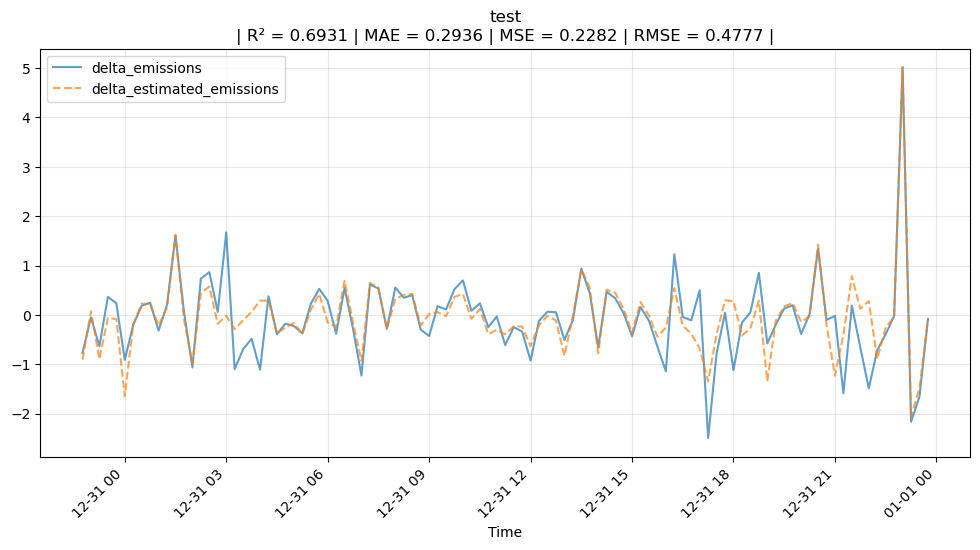

In [14]:
from marginal_emissions.utils.helper import *
import matplotlib.pyplot as plt
from scipy.stats import probplot, alpha
import numpy as np

plot_over_time(data=analyzer.final_df, tso='test_msdr', col1='delta_estimated_emissions', col2='delta_emissions', y_label=None, plot=True)

<Figure size 1000x600 with 0 Axes>

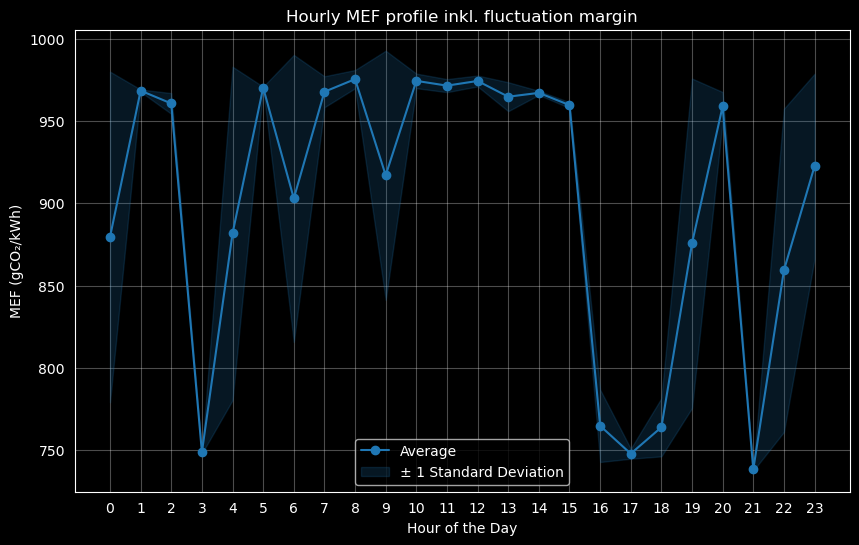

In [16]:
plot_df = analyzer.final_df.copy()

plt.figure(figsize=(10, 6))

# Compute average and mean
hourly_avg = plot_df.groupby(plot_df.index.hour)['mef_g_kWh'].mean()
hourly_std = plot_df.groupby(plot_df.index.hour)['mef_g_kWh'].std()

# Plot average
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='tab:blue', label='Average')

# Shaded area for sd
plt.fill_between(
    hourly_avg.index,
    hourly_avg - hourly_std,
    hourly_avg + hourly_std,
    color='tab:blue',
    alpha=0.2,
    label='± 1 Standard Deviation'
)

plt.title('Hourly MEF profile inkl. fluctuation margin')
plt.xlabel('Hour of the Day')
plt.ylabel('MEF (gCO₂/kWh)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()